loading annotations into memory...
Done (t=3.50s)
creating index...
index created!


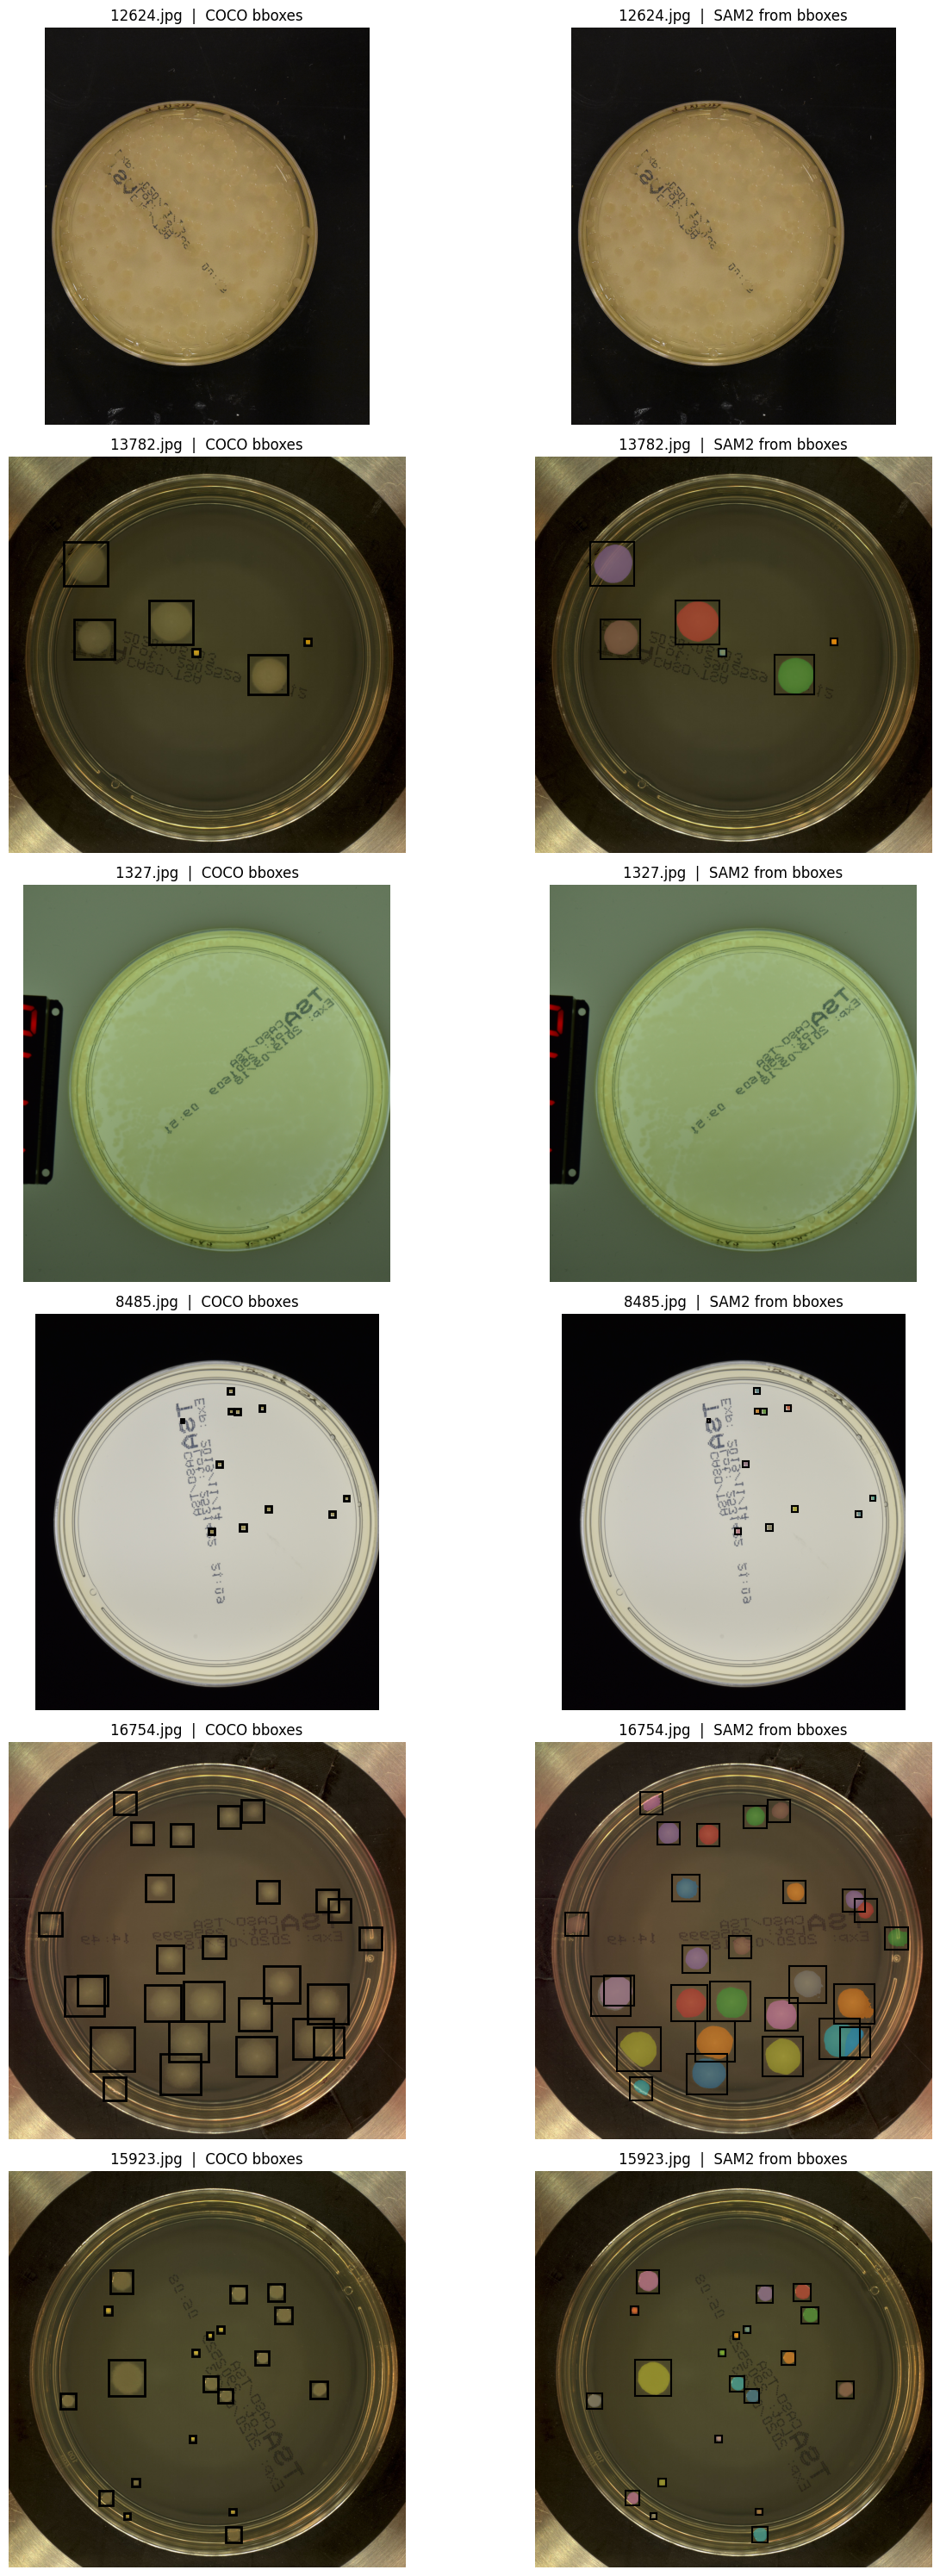

In [1]:
# Notebook cell: COCO viewer + Ultralytics SAM2 segmentation from COCO bboxes
#
# Expected folder layout:
#   <dataset_dir>/
#     annotations*.json   (COCO instances json; any *.json in this folder will be used)
#     (images may be in the same folder OR in common subfolders like images/, train/, val/, etc.)
#
# Requirements (run once if needed):
#   pip install -U ultralytics pycocotools opencv-python matplotlib pillow numpy

from __future__ import annotations

import os
import glob
import random
from dataclasses import dataclass
from typing import List, Optional, Sequence, Tuple, Union, Dict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

try:
    from pycocotools.coco import COCO
except Exception as e:
    raise ImportError("pycocotools is required. Install via: pip install pycocotools") from e

try:
    from ultralytics import SAM
except Exception as e:
    raise ImportError("ultralytics is required. Install via: pip install ultralytics") from e


# -------------------------
# Utilities
# -------------------------

COMMON_IMAGE_SUBDIRS = ("images", "img", "train", "val", "valid", "test", "dataset", "data")

def _find_coco_json(dataset_dir: str) -> str:
    jsons = sorted(glob.glob(os.path.join(dataset_dir, "*.json")))
    if not jsons:
        # sometimes annotations/instances*.json
        jsons = sorted(glob.glob(os.path.join(dataset_dir, "**", "*.json"), recursive=True))
    if not jsons:
        raise FileNotFoundError(f"No .json COCO annotation file found under: {dataset_dir}")
    # Prefer a typical COCO instances file name if present
    for cand in jsons:
        name = os.path.basename(cand).lower()
        if "instances" in name or "coco" in name or "annotations" in name:
            return cand
    return jsons[0]


def _resolve_image_path(dataset_dir: str, file_name: str) -> str:
    """
    COCO 'file_name' might be:
      - relative (e.g., '0001.png' or 'train/0001.png')
      - absolute
    We attempt a robust resolution strategy.
    """
    if os.path.isabs(file_name) and os.path.exists(file_name):
        return file_name

    # 1) direct join
    p = os.path.join(dataset_dir, file_name)
    if os.path.exists(p):
        return p

    # 2) search common subdirs
    for sub in COMMON_IMAGE_SUBDIRS:
        p2 = os.path.join(dataset_dir, sub, file_name)
        if os.path.exists(p2):
            return p2

    # 3) brute recursive basename match (last resort)
    base = os.path.basename(file_name)
    matches = glob.glob(os.path.join(dataset_dir, "**", base), recursive=True)
    matches = [m for m in matches if os.path.isfile(m)]
    if matches:
        return matches[0]

    raise FileNotFoundError(f"Could not resolve image path for COCO file_name='{file_name}' under '{dataset_dir}'")


def _load_rgb(image_path: str) -> np.ndarray:
    # Force RGB uint8
    im = Image.open(image_path).convert("RGB")
    return np.array(im)


def _coco_xywh_to_xyxy(b: Sequence[float]) -> Tuple[float, float, float, float]:
    x, y, w, h = b
    return (x, y, x + w, y + h)


def _draw_bboxes(ax, bboxes_xyxy: np.ndarray, labels: Optional[List[str]] = None, linewidth: float = 2.0):
    """
    Draw rectangles on a matplotlib axis.
    bboxes_xyxy: (N,4) as x1,y1,x2,y2 in pixel coords
    """
    import matplotlib.patches as patches

    for i, (x1, y1, x2, y2) in enumerate(bboxes_xyxy):
        rect = patches.Rectangle(
            (x1, y1), (x2 - x1), (y2 - y1),
            fill=False, linewidth=linewidth
        )
        ax.add_patch(rect)
        if labels:
            ax.text(x1, y1, labels[i], fontsize=10, verticalalignment="top", bbox=dict(facecolor="white", alpha=0.6))


def _overlay_masks(ax, masks: np.ndarray, alpha: float = 0.45):
    """
    Overlay boolean masks on axis.
    masks: (N,H,W) boolean or {0,1}
    We overlay each instance with a different color automatically (matplotlib default cycle).
    """
    if masks is None or len(masks) == 0:
        return

    # Ensure boolean
    masks = masks.astype(bool)
    h, w = masks.shape[-2], masks.shape[-1]

    # Create an RGBA overlay per mask using matplotlib color cycle
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0", "C1", "C2", "C3", "C4"])
    for i, m in enumerate(masks):
        if m.shape != (h, w):
            continue
        color = color_cycle[i % len(color_cycle)]
        # Make an RGBA image: color wherever mask is True
        overlay = np.zeros((h, w, 4), dtype=np.float32)
        rgb = np.array(plt.matplotlib.colors.to_rgb(color), dtype=np.float32)
        overlay[..., :3] = rgb
        overlay[..., 3] = m.astype(np.float32) * alpha
        ax.imshow(overlay)


@dataclass
class COCOImageSample:
    image_id: int
    file_name: str
    image_path: str
    bboxes_xyxy: np.ndarray  # (N,4)
    cat_ids: List[int]


def _get_samples_from_coco(
    coco: COCO,
    dataset_dir: str,
    image_ids: Sequence[int],
    max_boxes: Optional[int] = None,
    min_box_area: float = 1.0,
) -> List[COCOImageSample]:
    samples: List[COCOImageSample] = []

    for img_id in image_ids:
        img_info = coco.loadImgs([img_id])[0]
        file_name = img_info["file_name"]
        image_path = _resolve_image_path(dataset_dir, file_name)

        ann_ids = coco.getAnnIds(imgIds=[img_id], iscrowd=None)
        anns = coco.loadAnns(ann_ids)

        bboxes = []
        cat_ids = []
        for a in anns:
            if "bbox" not in a:
                continue
            x, y, w, h = a["bbox"]
            if w * h < min_box_area:
                continue
            bboxes.append(_coco_xywh_to_xyxy((x, y, w, h)))
            cat_ids.append(int(a.get("category_id", -1)))

        if len(bboxes) == 0:
            # keep sample but with empty bboxes; SAM2 will skip
            bboxes_xyxy = np.zeros((0, 4), dtype=np.float32)
        else:
            bboxes_xyxy = np.array(bboxes, dtype=np.float32)
            if max_boxes is not None and len(bboxes_xyxy) > max_boxes:
                bboxes_xyxy = bboxes_xyxy[:max_boxes]
                cat_ids = cat_ids[:max_boxes]

        samples.append(
            COCOImageSample(
                image_id=int(img_id),
                file_name=file_name,
                image_path=image_path,
                bboxes_xyxy=bboxes_xyxy,
                cat_ids=cat_ids,
            )
        )

    return samples


def _predict_sam2_from_bboxes(
    sam_model: SAM,
    image_rgb: np.ndarray,
    bboxes_xyxy: np.ndarray,
    device: Optional[str] = None,
):
    """
    Runs Ultralytics SAM2 using bbox prompts.

    Returns:
      masks: (N,H,W) boolean array (or None if unavailable)
      result_obj: raw ultralytics result for debugging
    """
    if bboxes_xyxy is None or len(bboxes_xyxy) == 0:
        return np.zeros((0, image_rgb.shape[0], image_rgb.shape[1]), dtype=bool), None

    # Ultralytics expects bboxes as a Python list (N,4). Pixel coords.
    bboxes_list = bboxes_xyxy.tolist()

    # The Ultralytics SAM API has shifted across versions; try the most common calling conventions.
    # We keep this robust rather than version-pinning.
    try:
        # Common: model.predict(image, bboxes=..., device=...)
        results = sam_model.predict(image_rgb, bboxes=bboxes_list, device=device, verbose=False)
    except TypeError:
        try:
            # Alternate: model(image, bboxes=...)
            results = sam_model(image_rgb, bboxes=bboxes_list, device=device, verbose=False)
        except Exception:
            # As a last resort, try without named args
            results = sam_model.predict(image_rgb)

    # results is typically a list with one element per image
    r0 = results[0] if isinstance(results, (list, tuple)) else results

    masks = None
    if hasattr(r0, "masks") and r0.masks is not None:
        # r0.masks.data usually: (N,H,W) torch tensor
        data = r0.masks.data
        try:
            import torch
            if isinstance(data, torch.Tensor):
                masks = data.detach().cpu().numpy().astype(bool)
            else:
                masks = np.array(data).astype(bool)
        except Exception:
            masks = np.array(data).astype(bool)

    if masks is None:
        # Ensure we return a consistent shape
        masks = np.zeros((0, image_rgb.shape[0], image_rgb.shape[1]), dtype=bool)

    return masks, r0


# -------------------------
# Main function
# -------------------------

def show_coco_sam2_grid(
    dataset_dir: str,
    n: int = 6,
    filenames: Optional[Sequence[str]] = None,
    seed: int = 0,
    sam2_weights: str = "sam2_b.pt",
    device: Optional[str] = None,
    max_boxes_per_image: Optional[int] = None,
    min_box_area: float = 1.0,
    figsize_per_row: Tuple[float, float] = (14.0, 5.0),
):
    """
    Displays a grid where each row is:
      LEFT : original image + COCO bounding boxes
      RIGHT: SAM2 segmentation overlaid, using those bboxes as prompts

    Inputs:
      dataset_dir: absolute path to folder containing a COCO annotation json somewhere inside (preferably in this folder)
      n: number of random images to display (ignored if filenames provided)
      filenames: optional list of COCO image 'file_name' strings to display instead of random
      sam2_weights: Ultralytics SAM2 checkpoint name/path (e.g. 'sam2_b.pt', 'sam2_s.pt', or an absolute path)
      device: e.g. 'cuda', 'cpu', 'mps' (None lets Ultralytics decide)
      max_boxes_per_image: optionally limit number of bboxes used as prompts (useful for very dense scenes)
      min_box_area: filter out tiny bboxes (w*h < min_box_area)
    """
    if not os.path.isabs(dataset_dir):
        raise ValueError("Please provide an absolute path for dataset_dir.")

    ann_path = _find_coco_json(dataset_dir)
    coco = COCO(ann_path)

    # Load SAM2 model once
    sam_model = SAM(sam2_weights)

    # Choose images
    all_img_ids = coco.getImgIds()
    if not all_img_ids:
        raise ValueError("No images found in COCO annotations.")

    if filenames and len(filenames) > 0:
        # Resolve COCO image IDs that match these filenames
        # Note: COCO doesn't have a direct index; do a lookup map.
        imgs = coco.loadImgs(all_img_ids)
        fname_to_id: Dict[str, int] = {im["file_name"]: int(im["id"]) for im in imgs}
        missing = [f for f in filenames if f not in fname_to_id]
        if missing:
            raise ValueError(
                "Some filenames were not found in COCO annotations:\n"
                + "\n".join(missing[:20])
                + ("\n..." if len(missing) > 20 else "")
            )
        chosen_ids = [fname_to_id[f] for f in filenames]
    else:
        rng = random.Random(seed)
        chosen_ids = rng.sample(all_img_ids, k=min(n, len(all_img_ids)))

    samples = _get_samples_from_coco(
        coco=coco,
        dataset_dir=dataset_dir,
        image_ids=chosen_ids,
        max_boxes=max_boxes_per_image,
        min_box_area=min_box_area,
    )

    # Plot: one row per image, 2 columns (bbox vs SAM2)
    num_rows = len(samples)
    fig_w, fig_h = figsize_per_row
    fig, axes = plt.subplots(
        num_rows, 2,
        figsize=(fig_w, fig_h * num_rows),
        squeeze=False
    )

    for row, s in enumerate(samples):
        image_rgb = _load_rgb(s.image_path)
        title = os.path.basename(s.file_name)

        # Left: boxes
        axL = axes[row, 0]
        axL.imshow(image_rgb)
        if len(s.bboxes_xyxy) > 0:
            _draw_bboxes(axL, s.bboxes_xyxy)
        axL.set_title(f"{title}  |  COCO bboxes")
        axL.axis("off")

        # Right: SAM2 masks from boxes
        axR = axes[row, 1]
        axR.imshow(image_rgb)

        masks, _raw = _predict_sam2_from_bboxes(
            sam_model=sam_model,
            image_rgb=image_rgb,
            bboxes_xyxy=s.bboxes_xyxy,
            device=device,
        )
        if masks is not None and len(masks) > 0:
            _overlay_masks(axR, masks, alpha=0.45)
        if len(s.bboxes_xyxy) > 0:
            _draw_bboxes(axR, s.bboxes_xyxy, linewidth=1.5)

        axR.set_title(f"{title}  |  SAM2 from bboxes")
        axR.axis("off")

    plt.tight_layout()
    plt.show()


# -------------------------
# Example usage
# -------------------------

# 1) Random N images
show_coco_sam2_grid(
    dataset_dir="D:/AGAR_dataset/AGAR_dataset/dataset",
    n=6,
    sam2_weights="sam2_b.pt",   # or a local path to the checkpoint
    device="cuda",             # optional
    max_boxes_per_image=50      # optional safeguard for very dense images
)

# 2) Specific files (must match COCO 'file_name' exactly)
# show_coco_sam2_grid(
#     dataset_dir="/absolute/path/to/your/coco_folder",
#     filenames=[
#         "train/000001.png",
#         "train/000002.png",
#     ],
#     sam2_weights="sam2_b.pt",
#     device="cuda",
# )


In [ ]:
# Notebook cell: Resume-capable SAM2 batch generation (skips already processed items)

from __future__ import annotations

import os
import json
import glob
from typing import Dict, List, Optional, Sequence

import numpy as np
from PIL import Image
import cv2

from pycocotools.coco import COCO
from ultralytics import SAM


COMMON_IMAGE_SUBDIRS = ("images", "img", "train", "val", "valid", "test", "dataset", "data")


def find_coco_json(dataset_dir: str) -> str:
    jsons = sorted(glob.glob(os.path.join(dataset_dir, "*.json")))
    if not jsons:
        jsons = sorted(glob.glob(os.path.join(dataset_dir, "**", "*.json"), recursive=True))
    if not jsons:
        raise FileNotFoundError(f"No COCO .json found under: {dataset_dir}")

    for cand in jsons:
        name = os.path.basename(cand).lower()
        if "instances" in name or "annotations" in name or "coco" in name:
            return cand
    return jsons[0]


def resolve_image_path(dataset_dir: str, file_name: str) -> str:
    if os.path.isabs(file_name) and os.path.exists(file_name):
        return file_name

    p = os.path.join(dataset_dir, file_name)
    if os.path.exists(p):
        return p

    for sub in COMMON_IMAGE_SUBDIRS:
        p2 = os.path.join(dataset_dir, sub, file_name)
        if os.path.exists(p2):
            return p2

    base = os.path.basename(file_name)
    matches = glob.glob(os.path.join(dataset_dir, "**", base), recursive=True)
    matches = [m for m in matches if os.path.isfile(m)]
    if matches:
        return matches[0]

    raise FileNotFoundError(f"Cannot resolve image file_name='{file_name}' under '{dataset_dir}'")


def load_rgb(image_path: str) -> np.ndarray:
    return np.array(Image.open(image_path).convert("RGB"))


def coco_xywh_to_xyxy(b: Sequence[float]) -> List[float]:
    x, y, w, h = b
    return [x, y, x + w, y + h]


def predict_sam2_from_bboxes(
    sam_model: SAM,
    image_rgb: np.ndarray,
    bboxes_xyxy: np.ndarray,
    device: Optional[str] = None,
) -> np.ndarray:
    h, w = image_rgb.shape[:2]
    if bboxes_xyxy is None or len(bboxes_xyxy) == 0:
        return np.zeros((0, h, w), dtype=bool)

    bboxes_list = bboxes_xyxy.tolist()

    try:
        results = sam_model.predict(image_rgb, bboxes=bboxes_list, device=device, verbose=False)
    except TypeError:
        results = sam_model(image_rgb, bboxes=bboxes_list, device=device, verbose=False)

    r0 = results[0] if isinstance(results, (list, tuple)) else results
    if getattr(r0, "masks", None) is None or r0.masks is None:
        return np.zeros((0, h, w), dtype=bool)

    data = r0.masks.data
    try:
        import torch
        if isinstance(data, torch.Tensor):
            masks = data.detach().cpu().numpy().astype(bool)
        else:
            masks = np.array(data).astype(bool)
    except Exception:
        masks = np.array(data).astype(bool)

    if masks.ndim == 2:
        masks = masks[None, ...]
    return masks


def save_instance_id_mask(
    masks: np.ndarray,
    out_path: str,
    overlap_policy: str = "small_overwrites",
) -> np.ndarray:
    if masks.ndim != 3:
        raise ValueError("masks must be (N,H,W)")

    n, h, w = masks.shape
    inst = np.zeros((h, w), dtype=np.uint16)

    if n == 0:
        Image.fromarray(inst, mode="I;16").save(out_path)
        return inst

    areas = masks.reshape(n, -1).sum(axis=1)

    if overlap_policy == "small_overwrites":
        order = np.argsort(areas)
    elif overlap_policy == "large_overwrites":
        order = np.argsort(-areas)
    elif overlap_policy == "first_wins":
        order = np.arange(n)
    elif overlap_policy == "last_wins":
        order = np.arange(n)
    else:
        raise ValueError(f"Unknown overlap_policy: {overlap_policy}")

    if overlap_policy == "first_wins":
        for idx in order:
            m = masks[idx]
            writeable = (inst == 0) & m
            inst[writeable] = idx + 1
    else:
        for idx in order:
            inst[masks[idx]] = idx + 1

    Image.fromarray(inst, mode="I;16").save(out_path)
    return inst


def instance_mask_to_yolo_polygon_line(
    instance_binary_mask: np.ndarray,
    class_id: int,
    eps_frac: float = 0.002,
    min_area: float = 4.0,
    keep_largest_contour: bool = True,
) -> Optional[str]:
    m = (instance_binary_mask.astype(np.uint8) * 255)
    h, w = m.shape[:2]

    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    if keep_largest_contour:
        contours = [max(contours, key=cv2.contourArea)]

    cnt = contours[0]
    area = float(cv2.contourArea(cnt))
    if area < min_area:
        return None

    eps = eps_frac * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, eps, True).reshape(-1, 2)
    if approx.shape[0] < 3:
        return None

    pts = []
    for (x, y) in approx:
        pts.append(f"{x / w:.6f}")
        pts.append(f"{y / h:.6f}")

    return f"{class_id} " + " ".join(pts)


def sam2_coco_to_instmask_and_yoloseg_resume(
    dataset_dir: str,
    out_dir: str,
    sam2_weights: str = "sam2_b.pt",
    device: Optional[str] = None,
    eps_frac: float = 0.002,
    min_box_area: float = 1.0,
    max_boxes_per_image: Optional[int] = None,
    overlap_policy: str = "small_overwrites",
    write_empty_label_files: bool = True,
    # NEW:
    skip_existing: bool = True,
    strict_skip: bool = False,
    force_redo: bool = False,
):
    """
    Resume-capable batch run.
    - If skip_existing=True, images with existing outputs are skipped.
    - If strict_skip=True, require mask+meta+label to exist to skip.
      If strict_skip=False, require mask+meta only (label optional).
    - force_redo overrides skipping for everything.
    """
    if not os.path.isabs(dataset_dir):
        raise ValueError("dataset_dir must be an absolute path.")
    os.makedirs(out_dir, exist_ok=True)

    masks_dir = os.path.join(out_dir, "masks_16bit")
    labels_dir = os.path.join(out_dir, "labels_yoloseg")
    meta_dir = os.path.join(out_dir, "meta")
    os.makedirs(masks_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)
    os.makedirs(meta_dir, exist_ok=True)

    ann_path = find_coco_json(dataset_dir)
    coco = COCO(ann_path)

    cats = coco.loadCats(coco.getCatIds())
    cats = sorted(cats, key=lambda c: int(c["id"]))
    category_id_to_class_id = {int(c["id"]): i for i, c in enumerate(cats)}
    classes = [c.get("name", str(c["id"])) for c in cats]

    # Save mapping files once
    with open(os.path.join(out_dir, "category_id_to_class_id.json"), "w") as f:
        json.dump(category_id_to_class_id, f, indent=2)
    with open(os.path.join(out_dir, "classes.json"), "w") as f:
        json.dump(classes, f, indent=2)

    sam_model = SAM(sam2_weights)

    img_ids = coco.getImgIds()
    total = len(img_ids)
    if total == 0:
        raise ValueError("No images found in COCO annotation.")

    skipped = 0
    processed = 0
    errors = 0

    for idx, img_id in enumerate(img_ids, start=1):
        img_info = coco.loadImgs([img_id])[0]
        file_name = img_info["file_name"]
        stem = os.path.splitext(os.path.basename(file_name))[0]

        inst_path = os.path.join(masks_dir, f"{stem}_inst.png")
        label_path = os.path.join(labels_dir, f"{stem}.txt")
        meta_path = os.path.join(meta_dir, f"{stem}.json")

        if not force_redo and skip_existing:
            mask_ok = os.path.exists(inst_path)
            meta_ok = os.path.exists(meta_path)
            label_ok = os.path.exists(label_path)

            if strict_skip:
                done = mask_ok and meta_ok and label_ok
            else:
                done = mask_ok and meta_ok

            if done:
                skipped += 1
                if idx % 200 == 0 or idx == total:
                    print(f"[{idx}/{total}] skipped={skipped} processed={processed} errors={errors}")
                continue

        try:
            image_path = resolve_image_path(dataset_dir, file_name)
            image_rgb = load_rgb(image_path)
            H, W = image_rgb.shape[:2]

            ann_ids = coco.getAnnIds(imgIds=[img_id], iscrowd=None)
            anns = coco.loadAnns(ann_ids)

            bboxes = []
            cat_ids = []
            ann_ids_kept = []

            for a in anns:
                if "bbox" not in a:
                    continue
                x, y, w, h = a["bbox"]
                if (w * h) < min_box_area:
                    continue
                bboxes.append(coco_xywh_to_xyxy(a["bbox"]))
                cat_ids.append(int(a.get("category_id", -1)))
                ann_ids_kept.append(int(a.get("id", -1)))

            bboxes_xyxy = np.array(bboxes, dtype=np.float32) if bboxes else np.zeros((0, 4), dtype=np.float32)

            if max_boxes_per_image is not None and len(bboxes_xyxy) > max_boxes_per_image:
                bboxes_xyxy = bboxes_xyxy[:max_boxes_per_image]
                cat_ids = cat_ids[:max_boxes_per_image]
                ann_ids_kept = ann_ids_kept[:max_boxes_per_image]

            masks = predict_sam2_from_bboxes(sam_model, image_rgb, bboxes_xyxy, device=device)

            inst_u16 = save_instance_id_mask(masks, inst_path, overlap_policy=overlap_policy)

            label_lines: List[str] = []
            instances_meta: List[Dict] = []

            num_instances = int(inst_u16.max())
            for inst_id in range(1, num_instances + 1):
                idx0 = inst_id - 1
                if idx0 >= len(cat_ids):
                    continue

                coco_cat = cat_ids[idx0]
                if coco_cat not in category_id_to_class_id:
                    continue
                class_id = category_id_to_class_id[coco_cat]

                bin_mask = (inst_u16 == inst_id)
                yolo_line = instance_mask_to_yolo_polygon_line(
                    instance_binary_mask=bin_mask,
                    class_id=class_id,
                    eps_frac=eps_frac,
                    min_area=4.0,
                    keep_largest_contour=True,
                )
                if yolo_line is not None:
                    label_lines.append(yolo_line)

                instances_meta.append({
                    "instance_id": int(inst_id),
                    "coco_category_id": int(coco_cat),
                    "yolo_class_id": int(class_id),
                    "source_bbox_xyxy": [float(x) for x in bboxes_xyxy[idx0].tolist()] if idx0 < len(bboxes_xyxy) else None,
                    "source_ann_id": int(ann_ids_kept[idx0]) if idx0 < len(ann_ids_kept) else None,
                })

            if label_lines or write_empty_label_files:
                with open(label_path, "w") as f:
                    f.write("\n".join(label_lines) + ("\n" if label_lines else ""))

            meta = {
                "image_id": int(img_id),
                "file_name": file_name,
                "image_path": image_path,
                "width": int(W),
                "height": int(H),
                "instance_mask_16bit": os.path.basename(inst_path),
                "num_instances": int(num_instances),
                "instances": instances_meta,
            }
            with open(meta_path, "w") as f:
                json.dump(meta, f, indent=2)

            processed += 1

        except Exception as e:
            errors += 1
            # Write a small error marker so you can see which ones failed if you want.
            # Comment out if you prefer not to write anything on failure.
            err_path = os.path.join(meta_dir, f"{stem}.error.txt")
            with open(err_path, "w") as f:
                f.write(repr(e))
            print(f"[ERROR] {file_name} -> {e}")

        if idx % 50 == 0 or idx == total:
            print(f"[{idx}/{total}] skipped={skipped} processed={processed} errors={errors}")

    print("Done.")
    print(f"Skipped:   {skipped}")
    print(f"Processed: {processed}")
    print(f"Errors:    {errors}")
    print(f"Instance masks: {masks_dir}")
    print(f"YOLO-SEG labels: {labels_dir}")
    print(f"Metadata: {meta_dir}")
    print(f"Class mapping: {os.path.join(out_dir, 'classes.json')}")


# -----------------------------
# Example run (your paths)
# -----------------------------
sam2_coco_to_instmask_and_yoloseg_resume(
    dataset_dir="D:/AGAR_dataset/AGAR_dataset/dataset",
    out_dir="D:/AGAR_dataset/AGAR_dataset/yoloseg_output",
    sam2_weights="sam2_b.pt",
    device="cuda",
    eps_frac=0.002,
    max_boxes_per_image=200,
    overlap_policy="small_overwrites",
    skip_existing=True,
    strict_skip=False,   # set True if you want to require label file as well
    force_redo=False,
)


In [ ]:
ß